# 📊 EDA — Parcours Client Multitouch
**Projet Marketing Data** · M2 Data Engineering · Paris Ynov Campus

Ce notebook explore le dataset synthétique de 50 000 clients et ~150 000 touchpoints
avant la mise en place du pipeline ETL. L'objectif est de comprendre la structure des
données, les distributions et les patterns de conversion par canal et segment.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Chargement des données brutes
clients     = pd.read_csv("../data/raw/clients.csv")
touchpoints = pd.read_csv("../data/raw/touchpoints.csv")

print(f"Clients     : {len(clients):,} lignes, {clients.shape[1]} colonnes")
print(f"Touchpoints : {len(touchpoints):,} lignes, {touchpoints.shape[1]} colonnes")

Clients     : 50,000 lignes, 5 colonnes
Touchpoints : 149,887 lignes, 9 colonnes


In [2]:
# Aperçu des données
print("=== CLIENTS ===")
display(clients.head())
print("\n=== TOUCHPOINTS ===")
display(touchpoints.head())
print("\n=== TYPES & VALEURS MANQUANTES ===")
display(clients.isnull().sum().rename("missing_clients"))
display(touchpoints.isnull().sum().rename("missing_touchpoints"))

=== CLIENTS ===


,client_id,age,segment,region,anciennete_mois
0,1,43,Premium,PACA,59
1,2,36,Standard,Nouvelle-Aquitaine,104
2,3,45,Churner,Occitanie,62
3,4,56,Churner,Île-de-France,58
4,5,35,Premium,Autres,32



=== TOUCHPOINTS ===


,client_id,touchpoint_id,canal,date,position,n_touches_total,is_first_touch,is_last_touch,converti
0,1,1,Email,2022-01-23,1,5,True,False,0
1,1,2,Instagram,2022-02-07,2,5,False,False,0
2,1,3,Instagram,2022-02-16,3,5,False,False,0
3,1,4,SEO,2022-02-27,4,5,False,False,0
4,1,5,Instagram,2022-03-04,5,5,False,True,0



=== TYPES & VALEURS MANQUANTES ===


client_id          0
age                0
segment            0
region             0
anciennete_mois    0
Name: missing_clients, dtype: int64

client_id          0
touchpoint_id      0
canal              0
date               0
position           0
n_touches_total    0
is_first_touch     0
is_last_touch      0
converti           0
Name: missing_touchpoints, dtype: int64

## 1. Distribution des segments clients et régions

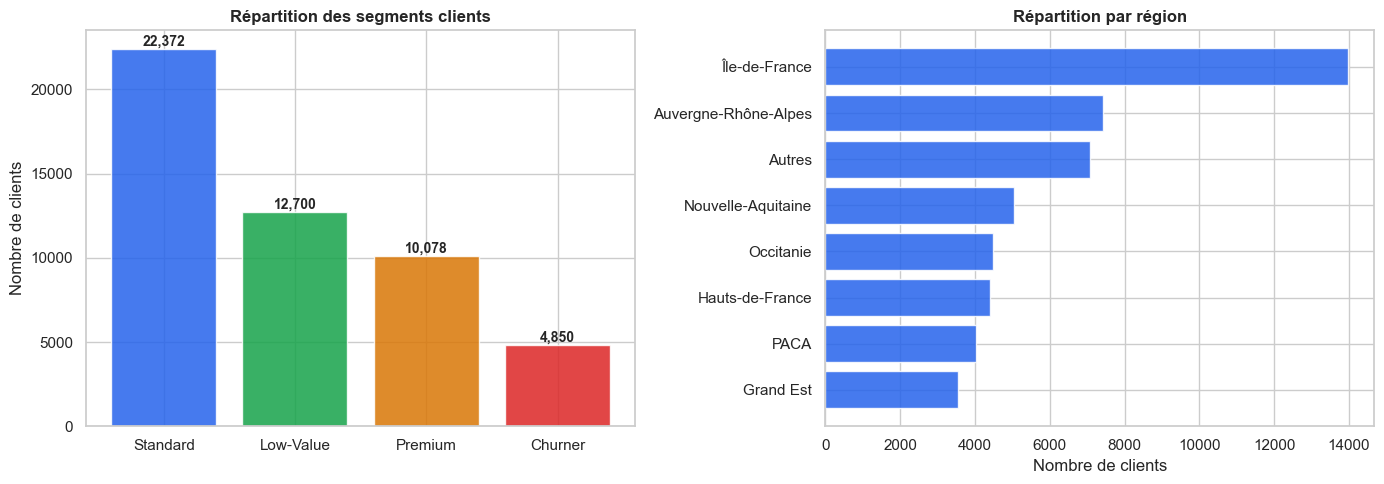


âge moyen : 37.8 ans
ancienneté moyenne : 60.3 mois


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segments
segments = clients["segment"].value_counts()
axes[0].bar(segments.index, segments.values, color=["#2563EB", "#16A34A", "#D97706", "#DC2626"], alpha=0.85)
axes[0].set_title("Répartition des segments clients", fontweight="bold")
axes[0].set_ylabel("Nombre de clients")
for i, (idx, val) in enumerate(segments.items()):
    axes[0].text(i, val + 200, f"{val:,}", ha="center", fontsize=10, fontweight="bold")

# Régions
regions = clients["region"].value_counts()
axes[1].barh(regions.index[::-1], regions.values[::-1], color="#2563EB", alpha=0.85)
axes[1].set_title("Répartition par région", fontweight="bold")
axes[1].set_xlabel("Nombre de clients")

plt.tight_layout()
plt.show()

print(f"\nâge moyen : {clients['age'].mean():.1f} ans")
print(f"ancienneté moyenne : {clients['anciennete_mois'].mean():.1f} mois")

## 2. Taux de conversion et distribution des touchpoints par canal

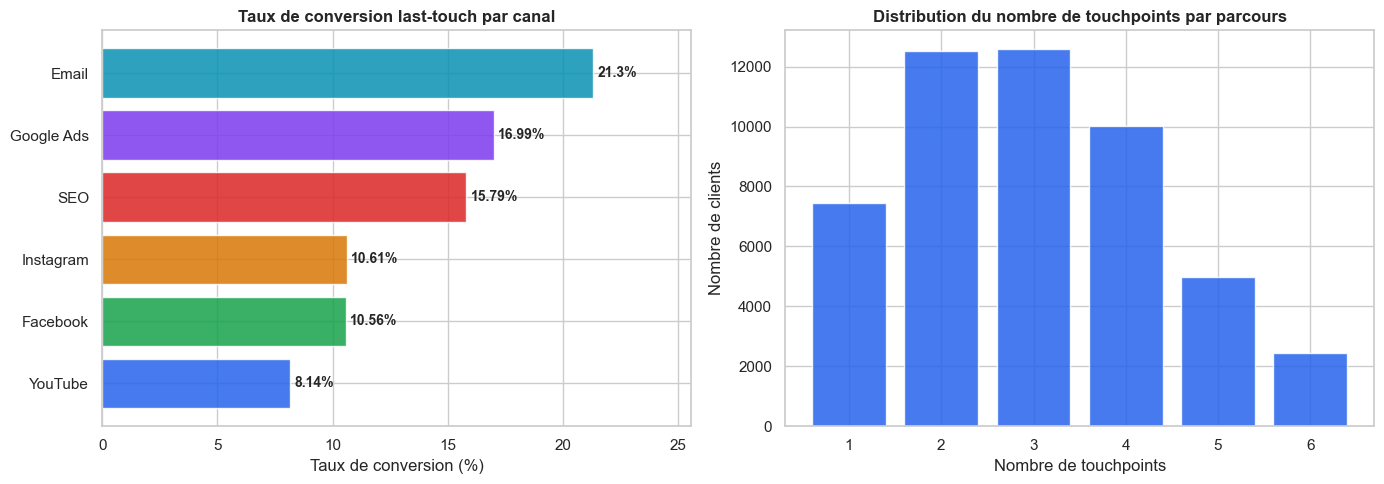

In [4]:
# Taux de conversion par canal (last touch uniquement)
last_touches = touchpoints[touchpoints["is_last_touch"] == True]
conv_canal = last_touches.groupby("canal").agg(
    nb_total=("converti", "count"),
    nb_conv=("converti", "sum")
).reset_index()
conv_canal["taux"] = (conv_canal["nb_conv"] / conv_canal["nb_total"] * 100).round(2)
conv_canal = conv_canal.sort_values("taux", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de conversion
couleurs = ["#2563EB", "#16A34A", "#D97706", "#DC2626", "#7C3AED", "#0891B2"]
axes[0].barh(conv_canal["canal"][::-1], conv_canal["taux"][::-1],
             color=couleurs, alpha=0.85)
for i, (_, row) in enumerate(conv_canal[::-1].iterrows()):
    axes[0].text(row["taux"] + 0.2, i, f"{row['taux']}%",
                 va="center", fontsize=10, fontweight="bold")
axes[0].set_title("Taux de conversion last-touch par canal", fontweight="bold")
axes[0].set_xlabel("Taux de conversion (%)")
axes[0].set_xlim(0, conv_canal["taux"].max() * 1.2)

# Distribution nombre de touchpoints
n_touches = touchpoints[touchpoints["is_last_touch"] == True]["n_touches_total"].value_counts().sort_index()
axes[1].bar(n_touches.index, n_touches.values, color="#2563EB", alpha=0.85)
axes[1].set_title("Distribution du nombre de touchpoints par parcours", fontweight="bold")
axes[1].set_xlabel("Nombre de touchpoints")
axes[1].set_ylabel("Nombre de clients")
axes[1].set_xticks(range(1, 7))

plt.tight_layout()
plt.show()

## 3. Taux de conversion par segment et canal

📊 Taux de conversion par segment :


,segment,taux,nb_conv,nb_total
2,Premium,27.61,2783,10078
3,Standard,17.07,3818,22372
1,Low-Value,7.28,924,12700
0,Churner,3.86,187,4850


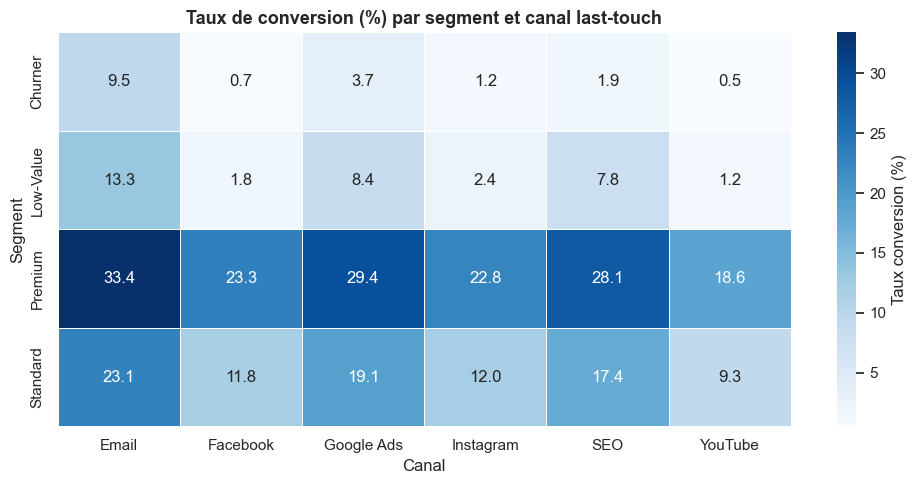

In [5]:
# Jointure touchpoints + clients
df = last_touches.merge(clients[["client_id", "segment"]], on="client_id", how="left")

# Taux de conversion par segment
conv_segment = df.groupby("segment").agg(
    nb_total=("converti", "count"),
    nb_conv=("converti", "sum")
).reset_index()
conv_segment["taux"] = (conv_segment["nb_conv"] / conv_segment["nb_total"] * 100).round(2)
conv_segment = conv_segment.sort_values("taux", ascending=False)

print("📊 Taux de conversion par segment :")
display(conv_segment[["segment", "taux", "nb_conv", "nb_total"]])

# Heatmap segment x canal
pivot = df.groupby(["segment", "canal"])["converti"].mean().unstack() * 100
pivot = pivot.round(2)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Taux conversion (%)"})
ax.set_title("Taux de conversion (%) par segment et canal last-touch",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Canal")
ax.set_ylabel("Segment")
plt.tight_layout()
plt.show()

## 4. Conclusions EDA

- **Email** est le canal le plus performant en last-touch (21.3%) — 
  il est positionné en fin de parcours et cible des clients déjà engagés
- **YouTube** est le moins performant (8.1%) mais joue un rôle de découverte
- Les clients **Premium** convertissent significativement mieux que les **Churners**
- La majorité des parcours comptent **2 à 3 touchpoints** avant conversion
- **Île-de-France** représente 28% de la base client, cohérent avec la démographie française

> Ces insights guident les choix de modélisation dans le pipeline ETL et le modèle Random Forest.